# Flow Cytometry Analysis — Python

Lightweight Python alternative for flow cytometry analysis.  
Covers: loading CSV and .fcs data, visualization, gating, clustering, and UMAP.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Dimensionality reduction & clustering
import umap
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.preprocessing import StandardScaler

# Flow-specific
try:
    import flowkit as fk
    HAS_FLOWKIT = True
except ImportError:
    HAS_FLOWKIT = False
    print("flowkit not installed — .fcs loading will use fcsparser as fallback")

try:
    import fcsparser
    HAS_FCSPARSER = True
except ImportError:
    HAS_FCSPARSER = False

plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10, 4)

## 2. Load data — CSV

In [2]:
csv_path = "../data/matrix_data.csv"
df = pd.read_csv(csv_path)
print(f"Shape: {df.shape}")
df.head()

Shape: (13982, 4)


,FSC-A,SSC-A,Alexa_488-A,PI-A
0,106737.00,34943.1,1182.820,115.2120
1,6390.56,13911.8,277.841,54.4942
2,252124.00,84884.6,4916.180,154.5880
3,262143.00,204461.0,5511.650,557.2780
4,262143.00,133109.0,4741.050,349.7930


In [3]:
df.describe()

,FSC-A,SSC-A,Alexa_488-A,PI-A
count,13982.000000,13982.000000,13982.000000,13982.000000
mean,124505.234895,60719.665134,11082.466061,663.858422
std,44495.263033,37896.108731,21429.143966,2168.966341
min,5136.560000,1004.150000,-40.202900,-149.687000
25%,107128.250000,39094.000000,2168.992500,73.315175
50%,122079.000000,50405.700000,3574.750000,116.726000
75%,139020.250000,67562.350000,6740.255000,182.421000
max,262143.000000,262143.000000,260470.000000,87389.000000


## 3. Load data — .fcs (optional)

In [4]:
fcs_path = "../data/sample.fcs"

if HAS_FLOWKIT:
    sample = fk.Sample(fcs_path)
    try:
        sample.apply_compensation(sample.metadata.get("spill"))
    except Exception:
        pass
    events = sample.as_dataframe(source="raw")
    print(f"Loaded with flowkit: {events.shape}")
elif HAS_FCSPARSER:
    meta, events = fcsparser.parse(fcs_path, reformat_meta=True)
    print(f"Loaded with fcsparser: {events.shape}")
else:
    print("No .fcs reader available. Install flowkit or fcsparser.")
    events = None

if events is not None:
    events.head()

Loaded with flowkit: (50000, 11)


## 4. Visualization

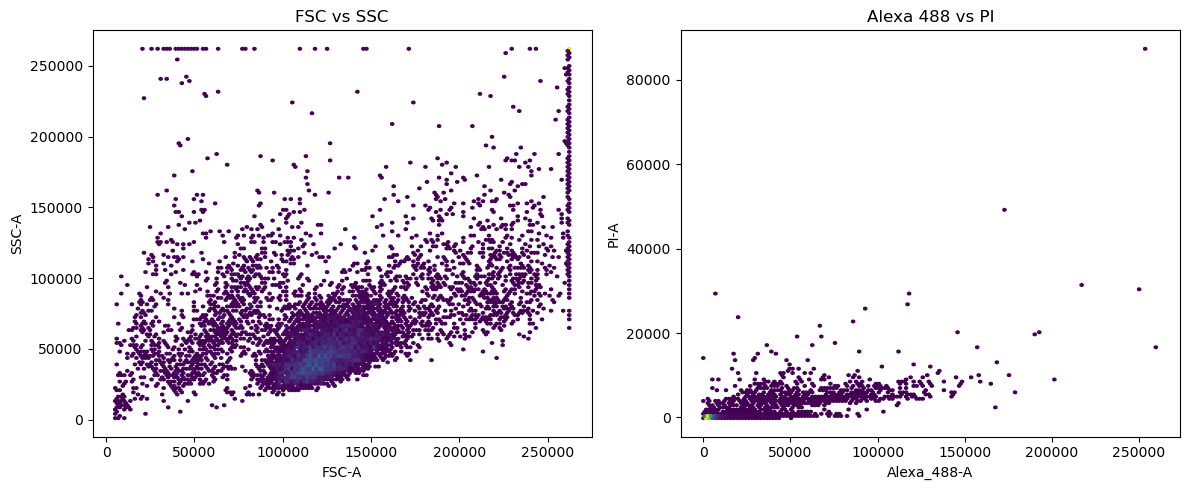

In [5]:
# Using df (CSV data) — substitute `events` for .fcs data
data = df.copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hexbin(data["FSC-A"], data["SSC-A"], gridsize=150, cmap="viridis", mincnt=1)
axes[0].set_xlabel("FSC-A")
axes[0].set_ylabel("SSC-A")
axes[0].set_title("FSC vs SSC")

axes[1].hexbin(data["Alexa_488-A"], data["PI-A"], gridsize=150, cmap="viridis", mincnt=1)
axes[1].set_xlabel("Alexa_488-A")
axes[1].set_ylabel("PI-A")
axes[1].set_title("Alexa 488 vs PI")

plt.tight_layout()
plt.show()

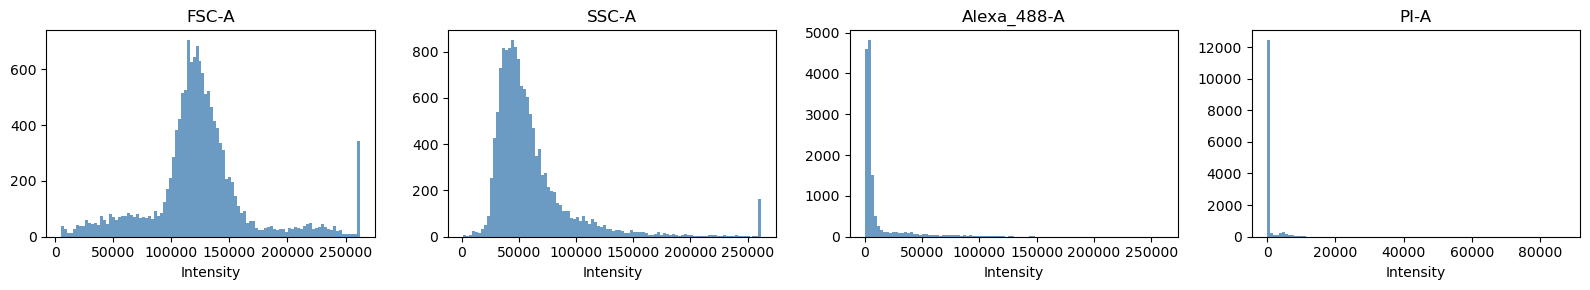

In [6]:
fig, axes = plt.subplots(1, len(data.columns), figsize=(4 * len(data.columns), 3))
for ax, col in zip(axes, data.columns):
    ax.hist(data[col], bins=100, color="steelblue", alpha=0.8)
    ax.set_title(col)
    ax.set_xlabel("Intensity")
plt.tight_layout()
plt.show()

## 5. Gating

In [7]:
# Scatter gate
fsc_min, fsc_max = 50000, 250000
ssc_max = 200000

mask_scatter = (data["FSC-A"] > fsc_min) & (data["FSC-A"] < fsc_max) & (data["SSC-A"] < ssc_max)
mask_live = mask_scatter & (data["PI-A"] < 500)
mask_positive = mask_live & (data["Alexa_488-A"] > 5000)

print(f"Total: {len(data)}")
print(f"Scatter gate: {mask_scatter.sum()}")
print(f"Live (PI-): {mask_live.sum()}")
print(f"Alexa 488+: {mask_positive.sum()}")

Total: 13982
Scatter gate: 12784
Live (PI-): 11634
Alexa 488+: 2685


## 6. UMAP & Clustering

In [8]:
gated = data[mask_live].copy()
channels = ["FSC-A", "SSC-A", "Alexa_488-A", "PI-A"]
mat = gated[channels].values

scaler = StandardScaler()
mat_scaled = scaler.fit_transform(mat)

# Subsample if large
np.random.seed(42)
n_sub = min(len(mat_scaled), 10000)
idx = np.random.choice(len(mat_scaled), n_sub, replace=False)
mat_sub = mat_scaled[idx]

# UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.2, random_state=42)
embedding = reducer.fit_transform(mat_sub)

# Clustering
km = KMeans(n_clusters=4, n_init=25, random_state=42)
clusters = km.fit_predict(mat_sub)

/opt/homebrew/Caskroom/mambaforge/base/envs/flow/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


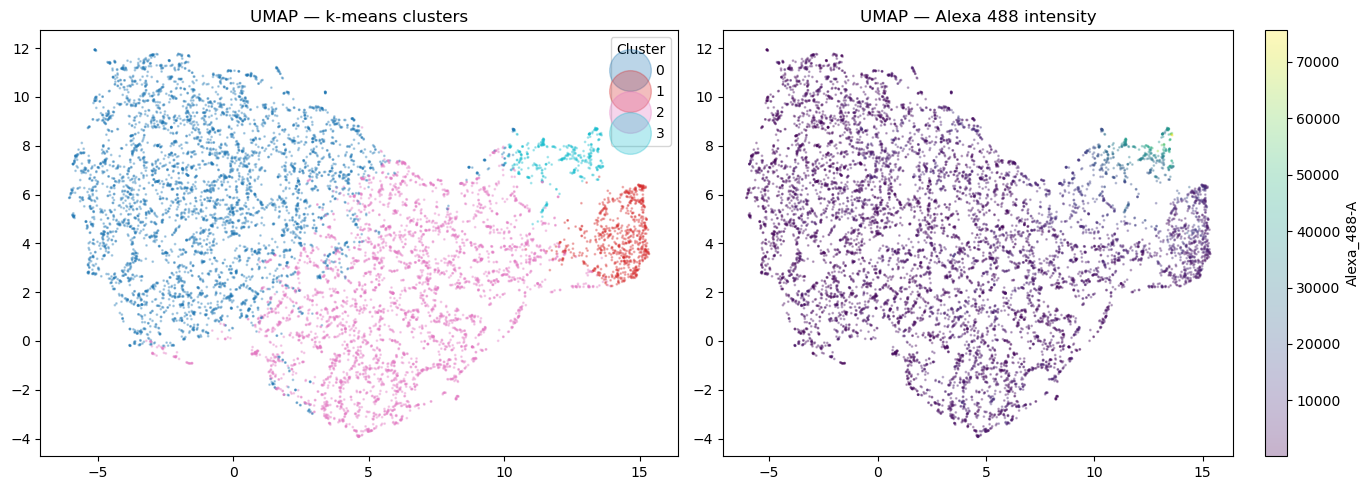

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

scatter = axes[0].scatter(embedding[:, 0], embedding[:, 1],
                           c=clusters, cmap="tab10", s=1, alpha=0.3)
axes[0].set_title("UMAP — k-means clusters")
axes[0].legend(*scatter.legend_elements(), title="Cluster", markerscale=5)

scatter2 = axes[1].scatter(embedding[:, 0], embedding[:, 1],
                            c=mat[idx, 2], cmap="viridis", s=1, alpha=0.3)  # Alexa 488
axes[1].set_title("UMAP — Alexa 488 intensity")
plt.colorbar(scatter2, ax=axes[1], label="Alexa_488-A")

plt.tight_layout()
plt.show()

## 7. Cluster summary

In [10]:
gated_sub = gated.iloc[idx].copy()
gated_sub["cluster"] = clusters

summary = gated_sub.groupby("cluster")[channels].median()
summary["n_events"] = gated_sub.groupby("cluster").size()
summary

,FSC-A,SSC-A,Alexa_488-A,PI-A,n_events
cluster,,,,,
0,116301.0,38760.20,2490.24,73.0261,5036
1,210265.0,97314.15,5558.74,209.1515,736
2,134371.0,57346.95,3537.10,135.1890,3870
3,130283.0,78685.45,30996.00,200.0230,358
